## Step 1: Data Loading
Load the dataset and inspect the first few records.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("../data/student_performance.csv")

# Display first 5 rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


**Observation**
- Dataset loaded successfully.
- The first five records help verify that the data has been imported correctly.

## Step 2: Dataset Overview
Check the dataset size, columns, and data types.

In [3]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns.tolist())

# Data types
print("\nData Types:\n")
df.dtypes

Shape: (6607, 20)

Columns:

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Data Types:



Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


## Step 6: Handle Missing Values
Fill missing values in categorical columns using the mode.

In [11]:
# Fill missing values with mode

categorical_cols = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

**Observation**
- Missing values were filled using the mode.
- The dataset now contains no missing values.

## Step 8: Exam Score Distribution
Visualize the distribution of the target variable.

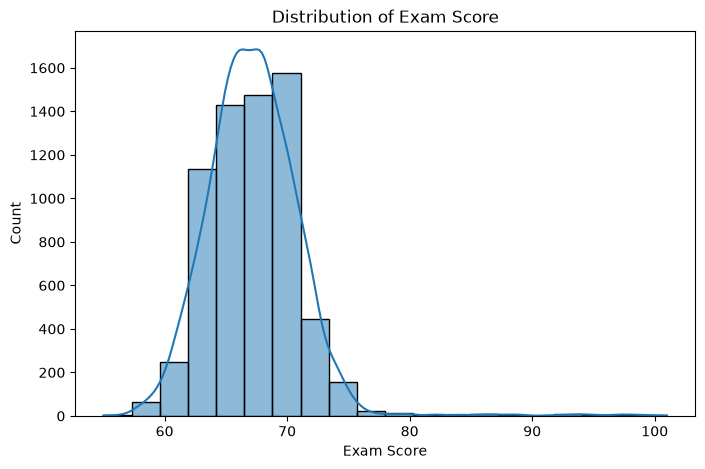

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Count")

plt.show()

## Step 9: Correlation Analysis
Check the relationship between numerical features.

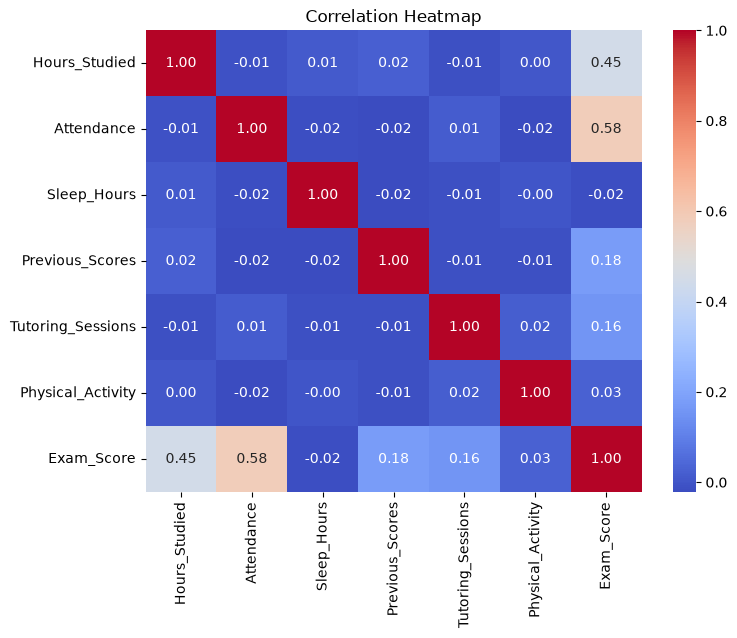

In [13]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Step 10: Hours Studied vs Exam Score
Analyze the relationship between study hours and exam score.

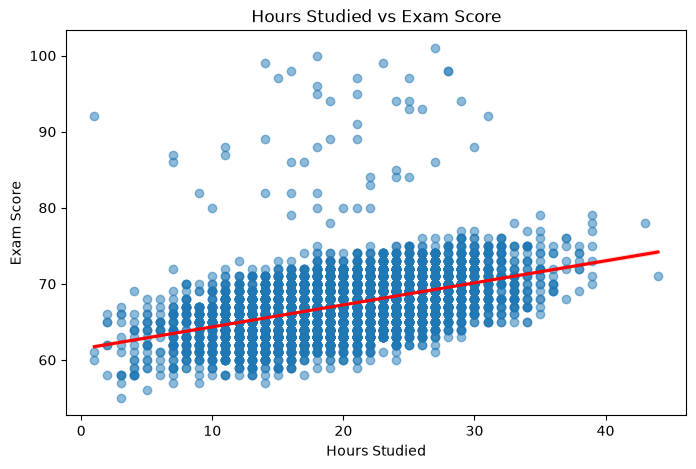

In [15]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

**Observation**
- Exam scores generally increase with study hours.
- The regression line indicates a positive relationship between the two variables.

## Step 11: Outlier Detection
Visualize outliers in numerical features.

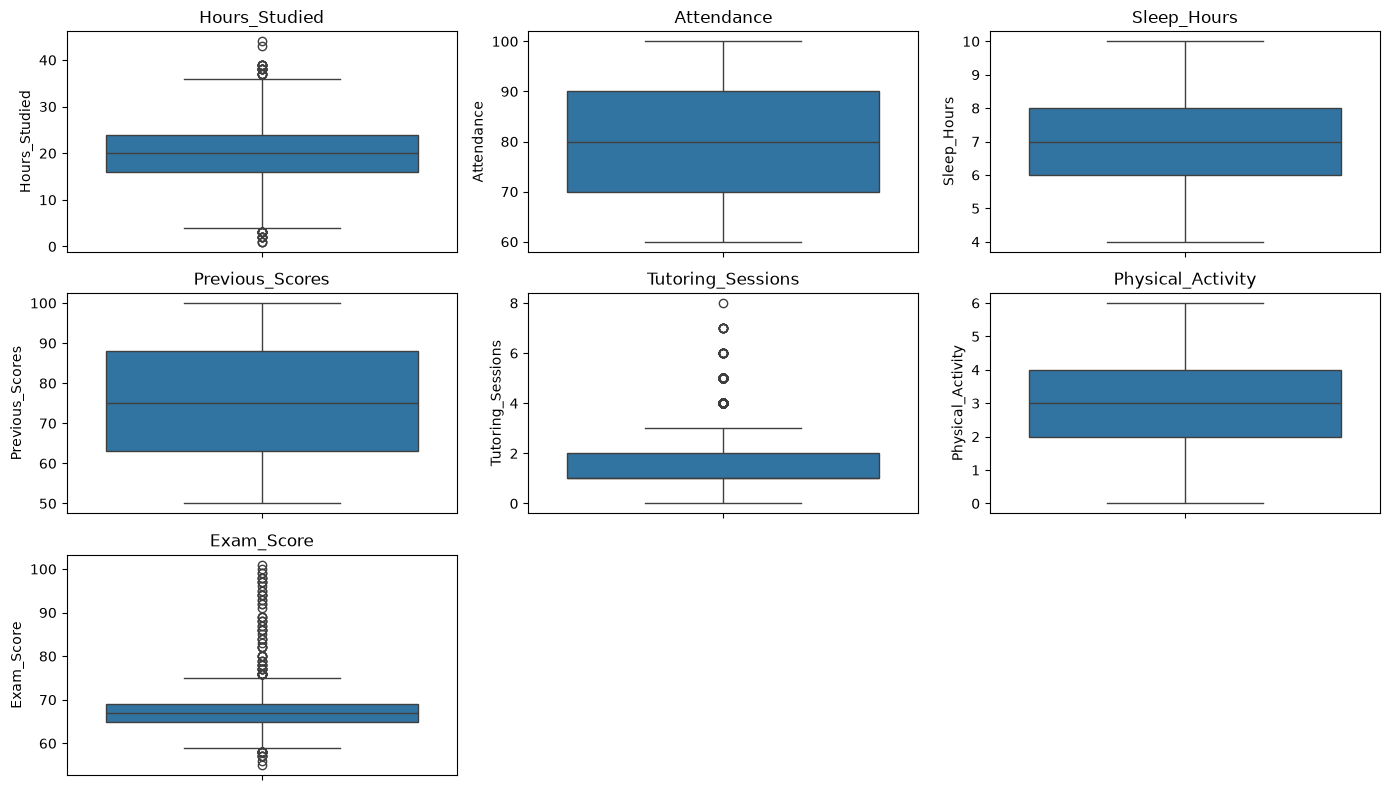

In [16]:
# Select numerical columns
numerical_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(14, 8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Observation**
- Hours_Studied, Tutoring_Sessions, and Exam_Score contain a few outliers.
- Most numerical features have a reasonable spread without extreme variation.

## Step 14: Encode Categorical Features
Convert categorical variables into numerical values.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_encoded = df.copy()

# Initialize Label Encoder
le = LabelEncoder()

# Encode categorical columns
categorical_cols = df_encoded.select_dtypes(include="object").columns

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Display first five rows
df_encoded.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_25632\676125283.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include="object").columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


In [18]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  School_Type                 6607 non-null   int64
 13  Peer_Influence              6607 non-null   int64
 14  Physical_Activity  

**Observation**
- All categorical features have been converted into numerical format.
- The dataset is now ready for model training.

## Step 15: Feature and Target Selection
Separate input features and target variable.

In [20]:
# Features
X = df_encoded.drop("Exam_Score", axis=1)

# Target
y = df_encoded["Exam_Score"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (6607, 19)
Target Shape  : (6607,)


**Observation**
- Features and target variable have been separated successfully.

## Step 16: Train-Test Split
Split the dataset into training and testing sets.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (5285, 19)
Testing Set  : (1322, 19)


**Observation**
- The dataset is split into 80% training and 20% testing data.

## Step 17: Feature Scaling
Standardize numerical features.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


**Observation**
- Features have been standardized for model training.

## Step 18: Linear Regression
Train the Linear Regression model.

In [24]:
from sklearn.linear_model import LinearRegression

# Train model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Observation**
- Linear Regression model has been trained successfully.

## Step 19: Model Prediction
Predict exam scores using the trained model.

In [25]:
# Prediction
y_pred_lr = lr_model.predict(X_test_scaled)

**Observation**
- Predictions have been generated for the test dataset.

## Step 20: Model Evaluation
Evaluate the Linear Regression model.

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.02
RMSE : 2.10
R²   : 0.6888


**Observation**
- Linear Regression achieved an R² score of 0.6888.
- The model provides a good baseline with low prediction error.